**Objetivo**
- Entorno: conoce el mapa y las recompensas.
- Agente: conoce su posición y sabe ejecutar acciones.
- Usuario: decide qué acción realizar (mediante el teclado).

Aun no se usar RL, ni Q-Learning

/tmp/ipykernel_15293/913031105.py:150: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.pause(0.6)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


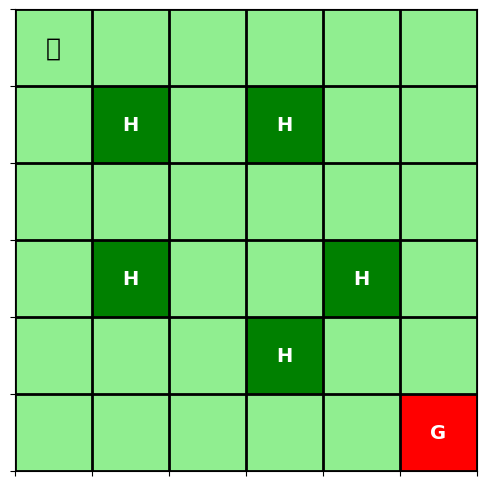

CONTROL DEL ROBOT
W -> Arriba
S -> Abajo
A -> Izquierda
D -> Derecha
Q -> Salir


KeyboardInterrupt: Interrupted by user

In [2]:
"""
=========================================================
LABORATORIO DE REINFORCEMENT LEARNING
VERSIÓN 2
AGENTE Y MOVIMIENTOS
=========================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ======================================================
# CONFIGURACIÓN
# ======================================================

N = 6

# Estados
# 0  -> Tierra
# -1 -> Agujero
# 1  -> Meta

environment = np.zeros((N, N), dtype=int)

holes = [
    (1,1),
    (1,3),
    (3,1),
    (3,4),
    (4,3)
]

for h in holes:
    environment[h] = -1

goal = (5,5)
environment[goal] = 1

# ======================================================
# RECOMPENSAS
# ======================================================

rewards = np.full((N,N), -1)

for h in holes:
    rewards[h] = -10

rewards[goal] = 10

# ======================================================
# CLASE AGENTE
# ======================================================

class Agent:

    def __init__(self):

        self.start = (0,0)
        self.position = self.start

    def reset(self):

        self.position = self.start

    def move(self, action):

        row, col = self.position

        if action == 0:      # Arriba
            row -= 1

        elif action == 1:    # Abajo
            row += 1

        elif action == 2:    # Izquierda
            col -= 1

        elif action == 3:    # Derecha
            col += 1

        # No salir del tablero
        row = max(0, min(N-1, row))
        col = max(0, min(N-1, col))

        self.position = (row, col)

        reward = rewards[row, col]

        return self.position, reward


# ======================================================
# VISUALIZACIÓN
# ======================================================

def draw_world(agent):

    colors = ListedColormap([
        "green",       # agujero
        "lightgreen",  # tierra
        "red"          # meta
    ])

    display = environment + 1

    plt.clf()

    plt.imshow(display, cmap=colors)

    plt.xticks(np.arange(-.5, N, 1), [])
    plt.yticks(np.arange(-.5, N, 1), [])

    plt.grid(color='black', linewidth=2)

    for i in range(N):
        for j in range(N):

            if environment[i,j] == -1:
                txt = "H"

            elif environment[i,j] == 1:
                txt = "G"

            else:
                txt = ""

            plt.text(
                j,
                i,
                txt,
                ha="center",
                va="center",
                fontsize=14,
                color="white",
                weight="bold"
            )

    r,c = agent.position

    plt.text(
        c,
        r,
        "🤖",
        fontsize=18,
        ha="center",
        va="center"
    )

    plt.pause(0.6)

# ======================================================
# PROGRAMA PRINCIPAL
# ======================================================

agent = Agent()

plt.figure(figsize=(6,6))

draw_world(agent)

print("="*50)
print("CONTROL DEL ROBOT")
print("="*50)

print("W -> Arriba")
print("S -> Abajo")
print("A -> Izquierda")
print("D -> Derecha")
print("Q -> Salir")

while True:

    cmd = input("\nMovimiento: ").upper()

    if cmd == "Q":
        break

    if cmd == "W":
        action = 0

    elif cmd == "S":
        action = 1

    elif cmd == "A":
        action = 2

    elif cmd == "D":
        action = 3

    else:
        print("Movimiento inválido")
        continue

    state, reward = agent.move(action)

    print(f"Estado actual : {state}")
    print(f"Recompensa    : {reward}")

    if reward == -10:
        print("⚠️ El robot cayó en un agujero.")

    if reward == 10:
        print("🎉 ¡El robot llegó a la meta!")

    draw_world(agent)

plt.show()